# Project 1: Business Summary & Recommendations
### NCR (Region 3) — Fault Ticket Performance Analysis

---

| | |
|---|---|
| **Scope** | NCR (Region 3) · 38,319 tickets · 6 operational zones |
| **Period** | January 2022 – May 2023 |
| **Objective** | Benchmark zone-level performance and surface actionable operational improvements |
| **Audience** | Operations Leadership / Portfolio Review |

---

### Ticket Lifecycle & Metric Definitions

```
REPORTDATE ──────────────► DISPATCHDATE ──────────────► RESOLVEDDATE
     │                           │                            │
     │◄── NOC/ROC Time ─────────►│◄──── Field Engr Time ─────►│
     │                                                         │
     │◄────────────────── Total MTTR (OUTAGEDURATION) ────────►│
```

| Metric | Formula | What it measures |
|--------|---------|-----------------|
| **NOC/ROC Time** | `DISPATCHDATE − REPORTDATE` | Time NOC/ROC spent on remote troubleshooting before endorsing to field. Zero is valid — some faults are immediately identified as field-only |
| **Field Engineer Time** | `RESOLVEDDATE − DISPATCHDATE` | Time from WO assignment to on-site resolution |
| **Total MTTR** | `OUTAGEDURATION` = `RESOLVEDDATE − REPORTDATE` | Full cycle from NOC opening ticket to close — includes both phases |

In [1]:
import sys, os
import pandas as pd
import numpy as np
from IPython.display import display, Markdown, Image
%matplotlib inline

os.chdir(os.path.join('..', '..'))
if os.path.abspath(os.getcwd()) not in sys.path:
    sys.path.insert(0, os.path.abspath(os.getcwd()))

from src.fault_ticket.metrics import calculate_zone_summary

df      = pd.read_csv('output/cleaned_fault_ticket.csv')
summary = calculate_zone_summary(df)
# calculate_zone_summary() now returns Avg_NOC_Time and Avg_Field_Time directly.
# Timestamp_Integrity filtering is applied inside calculate_noc_time() and
# calculate_field_time() — no manual column computation needed here.

# Parse REPORTDATE for date range display only
if 'REPORTDATE' in df.columns:
    df['REPORTDATE'] = pd.to_datetime(df['REPORTDATE'], errors='coerce')

# Zone references
z = {row['ZONE']: row for _, row in summary.iterrows()}
z5, z4, z2, z3, z1, z6 = (z.get(f'ZONE {i}') for i in [5, 4, 2, 3, 1, 6])

total_tickets = summary['Ticket_Count'].sum()
avg_sla       = summary['SLA_Compliance_Rate'].mean()
avg_mttr      = summary['MTTR'].mean()
avg_noc       = summary['Avg_NOC_Time'].mean()
avg_field     = summary['Avg_Field_Time'].mean()
total_sites   = summary['Unique_Sites'].sum()
date_min      = df['REPORTDATE'].min().strftime('%b %Y') if 'REPORTDATE' in df.columns else 'Jan 2022'
date_max      = df['REPORTDATE'].max().strftime('%b %Y') if 'REPORTDATE' in df.columns else 'May 2023'

print(f"✅ {total_tickets:,} tickets · {len(summary)} zones")
print(f"   Columns: {list(summary.columns)}")
print(f"   Avg NOC Time  : {avg_noc:.1f}h")
print(f"   Avg Field Time: {avg_field:.1f}h")
print(f"   Avg MTTR      : {avg_mttr:.1f}h")

✅ 36,907 tickets · 6 zones
   Columns: ['ZONE', 'Ticket_Count', 'MTTR', 'SLA_Compliance_Rate', 'Total_Faults', 'Unique_Sites', 'Fault_Density', 'Avg_NOC_Time', 'Avg_Field_Time']
   Avg NOC Time  : 3.8h
   Avg Field Time: 55.1h
   Avg MTTR      : 56.8h


## 1. Executive Summary

In [2]:
metrics = pd.DataFrame({
    'KPI'    : [
        'Total Tickets', 'Unique Sites', 'SLA Compliance',
        'Avg Total MTTR',
        'Avg NOC/ROC Time',
        'Avg Field Engineer Time',
        'Avg Fault Density'
    ],
    'Value'  : [
        f"{total_tickets:,}",
        f"{total_sites:,}",
        f"{avg_sla:.1f}%",
        f"{avg_mttr:.1f} hrs",
        f"{avg_noc:.1f} hrs",
        f"{avg_field:.1f} hrs",
        f"{summary['Fault_Density'].mean():.1f} faults/site"
    ],
    'Definition': [
        f"{date_min} – {date_max}",
        'Across 6 NCR zones',
        'Target: tier-dependent (P1≤3h, P2≤6h, P3≤9-24h, P4≤72h)',
        'RESOLVEDDATE − REPORTDATE  (full cycle)',
        'DISPATCHDATE − REPORTDATE  (remote phase · timestamp-clean tickets only)',
        'RESOLVEDDATE − DISPATCHDATE  (on-site phase · timestamp-clean tickets only)',
        'Zone 1 highest at 9.4 · Zone 3 lowest at 6.6'
    ]
})

display(metrics.style
    .hide(axis='index')
    .set_caption('Table 1 — NCR Performance Snapshot')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size','13px'),('font-weight','bold'),('text-align','left'),('padding-bottom','6px')]},
        {'selector': 'th',
         'props': [('background-color','#2c3e50'),('color','white'),('font-size','12px'),('padding','8px 12px')]},
        {'selector': 'td',
         'props': [('padding','7px 12px'),('font-size','12px')]},
        {'selector': 'tr:nth-child(even)',
         'props': [('background-color','#f7f9fc')]},
    ])
)

KPI,Value,Definition
Total Tickets,"36,907",Jan 2022 – May 2023
Unique Sites,"4,741",Across 6 NCR zones
SLA Compliance,82.1%,"Target: tier-dependent (P1≤3h, P2≤6h, P3≤9-24h, P4≤72h)"
Avg Total MTTR,56.8 hrs,RESOLVEDDATE − REPORTDATE (full cycle)
Avg NOC/ROC Time,3.8 hrs,DISPATCHDATE − REPORTDATE (remote phase · timestamp-clean tickets only)
Avg Field Engineer Time,55.1 hrs,RESOLVEDDATE − DISPATCHDATE (on-site phase · timestamp-clean tickets only)
Avg Fault Density,7.9 faults/site,Zone 1 highest at 9.4 · Zone 3 lowest at 6.6


## 2. Performance Dashboard

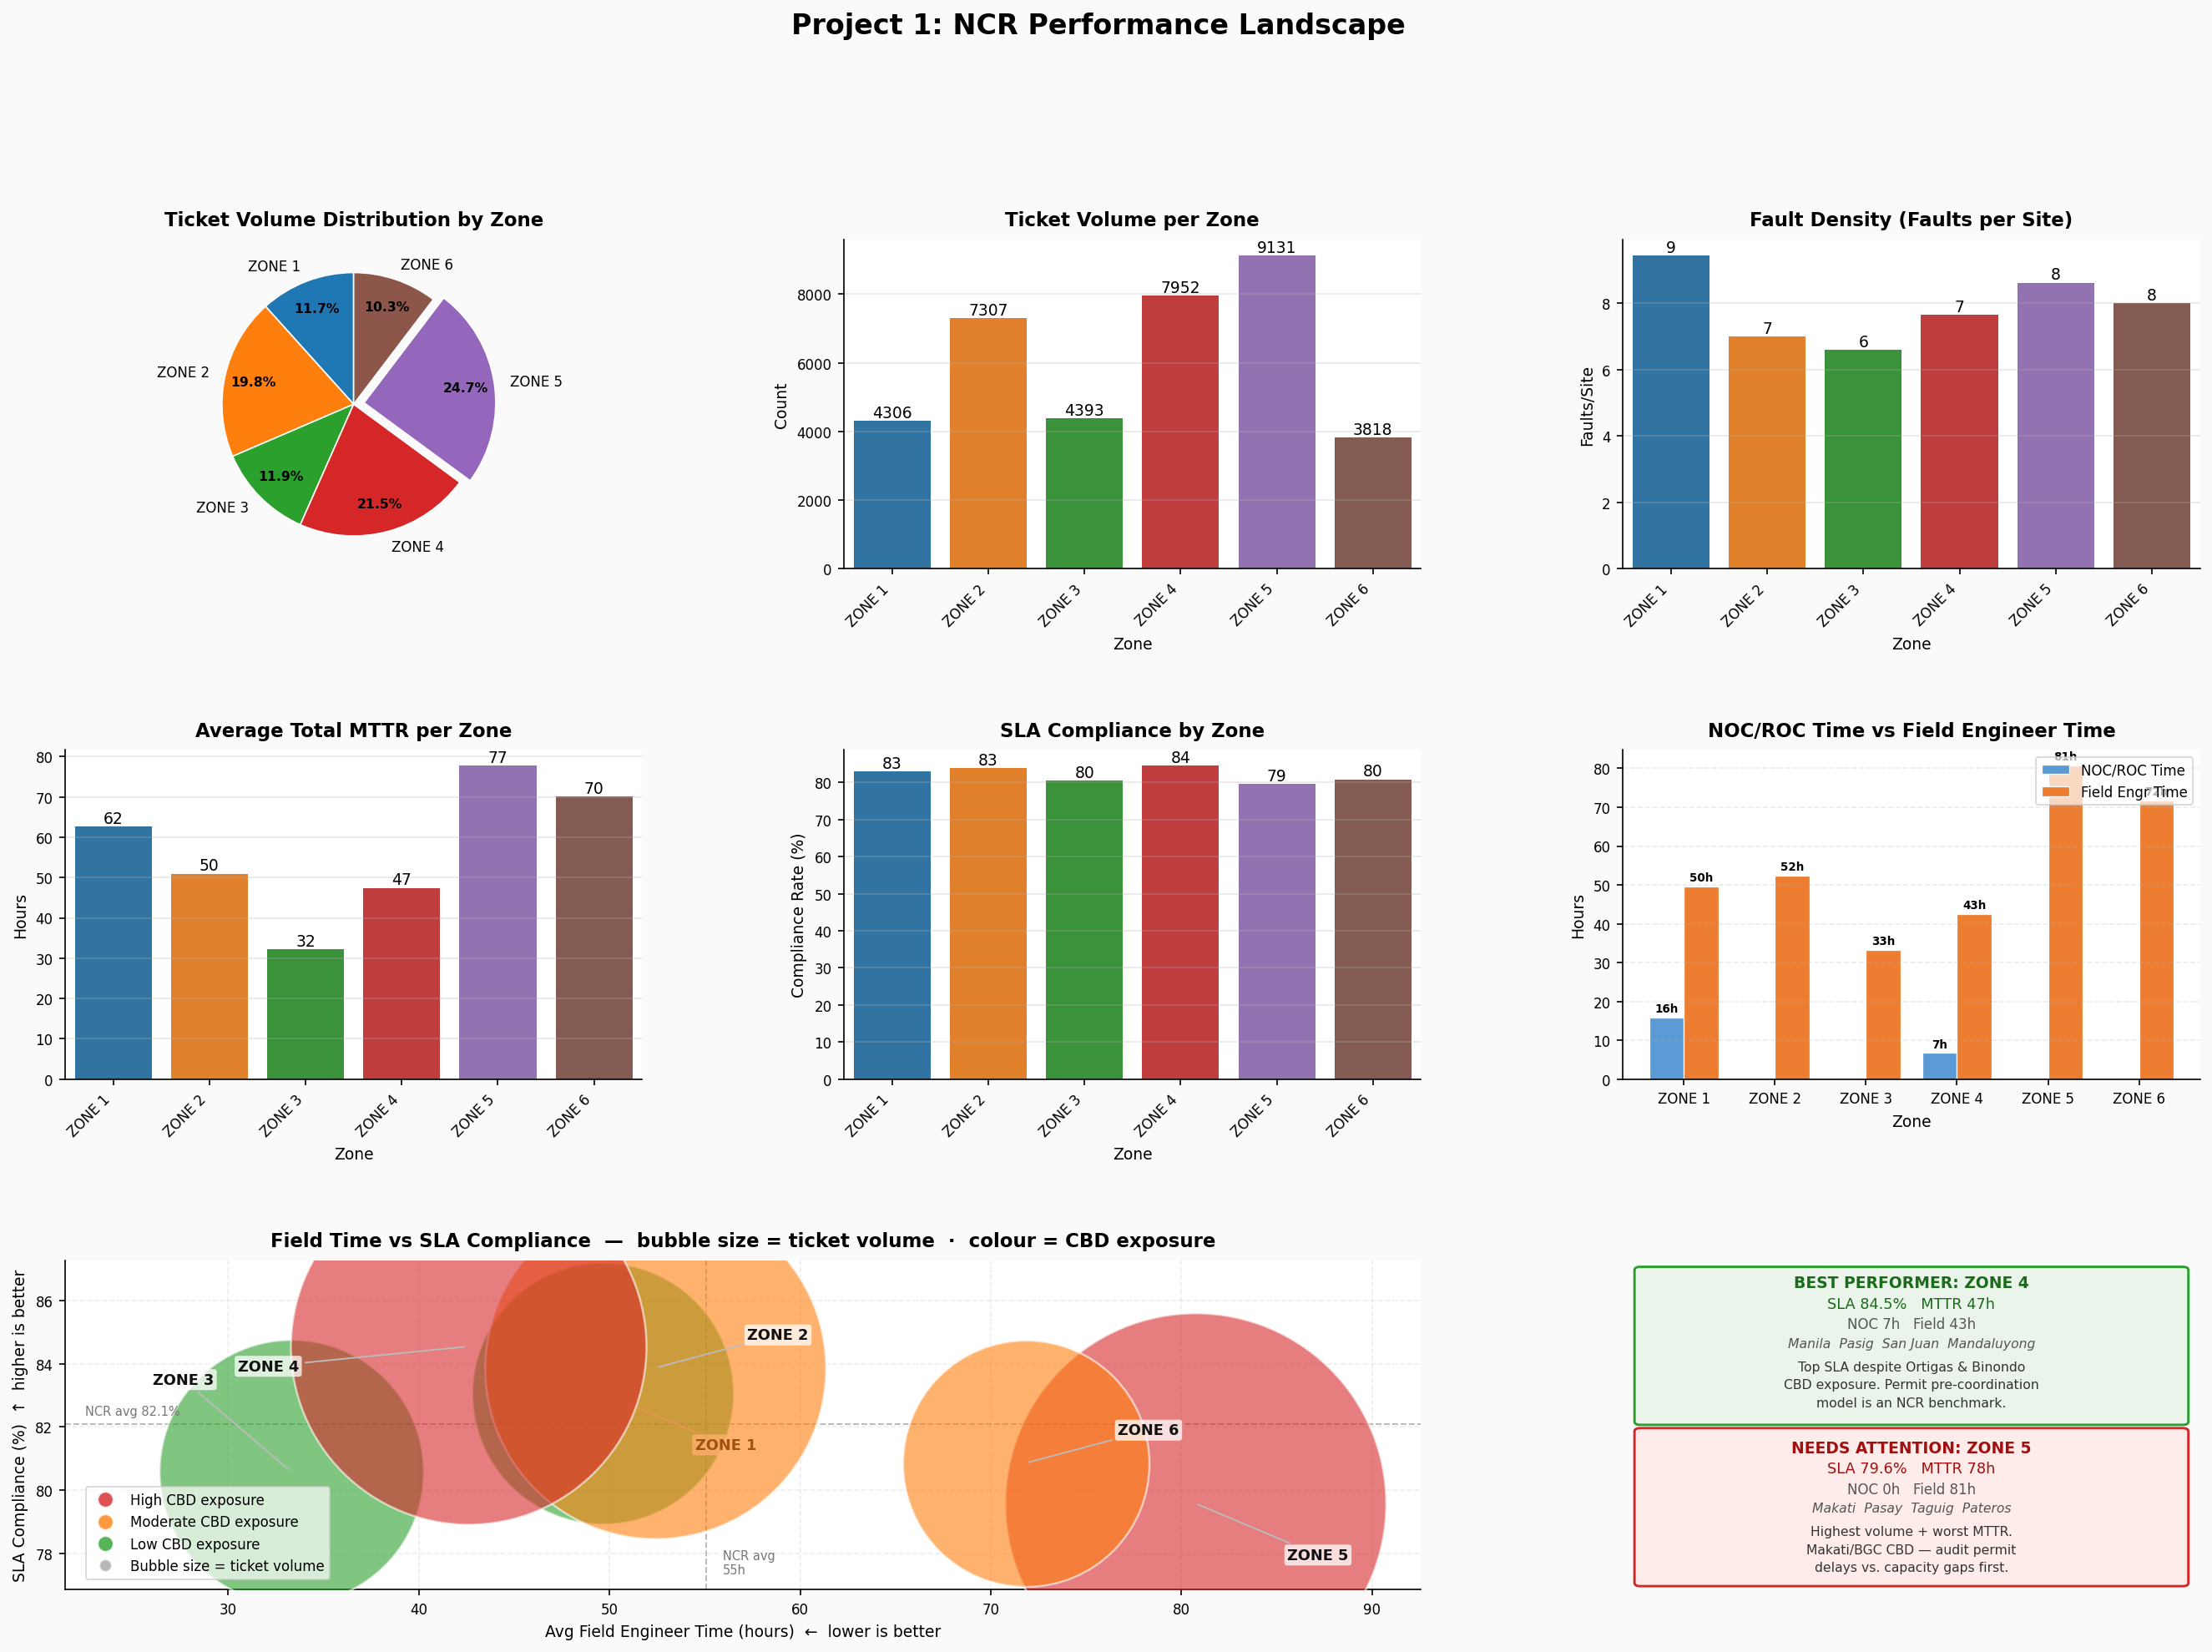

In [3]:
try:
    display(Image('reports/figures/project1_ncr/comprehensive_analysis.png', width=1350))
except FileNotFoundError:
    print("⚠️  Run Notebook 04 to generate the dashboard image.")

## 3. Zone Performance Comparison

In [4]:
cols = ['ZONE', 'Ticket_Count', 'SLA_Compliance_Rate', 'MTTR',
        'Avg_NOC_Time', 'Avg_Field_Time', 'Fault_Density']
tbl = summary[cols].reset_index(drop=True).copy()

# Composite rank across 5 KPIs (1 = best)
sc = tbl.copy()
sc['R_SLA']       = sc['SLA_Compliance_Rate'].rank(ascending=False, method='min')
sc['R_MTTR']      = sc['MTTR'].rank(method='min')
sc['R_NOC']       = sc['Avg_NOC_Time'].rank(method='min')
sc['R_Field']     = sc['Avg_Field_Time'].rank(method='min')
sc['R_Density']   = sc['Fault_Density'].rank(method='min')
sc['Composite']   = sc[['R_SLA','R_MTTR','R_NOC','R_Field','R_Density']].mean(axis=1)

n = len(sc)
def rating(r):
    p = r / n
    if p <= 0.25: return '🟢 Excellent'
    if p <= 0.50: return '🟡 Good'
    if p <= 0.75: return '🟠 Needs Attention'
    return '🔴 Critical'

tbl['Rating']    = sc['Composite'].apply(rating).values
tbl['Composite'] = sc['Composite'].values
tbl = tbl.sort_values('Composite').drop(columns='Composite').reset_index(drop=True)

display(tbl.style
    .hide(axis='index')
    .format({
        'Ticket_Count'        : '{:,.0f}',
        'SLA_Compliance_Rate' : '{:.1f}%',
        'MTTR'                : '{:.1f}h',
        'Avg_NOC_Time'        : '{:.1f}h',
        'Avg_Field_Time'      : '{:.1f}h',
        'Fault_Density'       : '{:.2f}',
    })
    .background_gradient(subset=['SLA_Compliance_Rate'], cmap='Greens',   vmin=70, vmax=90)
    .background_gradient(subset=['MTTR'],                cmap='RdYlGn_r', vmin=30, vmax=80)
    .background_gradient(subset=['Avg_NOC_Time'],        cmap='RdYlGn_r', vmin=0,  vmax=90)
    .background_gradient(subset=['Avg_Field_Time'],      cmap='RdYlGn_r', vmin=0,  vmax=80)
    .background_gradient(subset=['Fault_Density'],       cmap='RdYlGn_r', vmin=6,  vmax=10)
    .set_caption(
        'Table 2 — Zone Scorecard (best → worst composite rank) · '
        'NOC/ROC Time = remote troubleshooting phase · Field Time = on-site resolution phase'
    )
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size','13px'),('font-weight','bold'),('text-align','left'),('padding-bottom','6px')]},
        {'selector': 'th',
         'props': [('background-color','#2c3e50'),('color','white'),('font-size','12px'),('padding','8px 12px')]},
        {'selector': 'td',
         'props': [('padding','7px 12px'),('font-size','12px'),('text-align','center')]},
    ])
)

ZONE,Ticket_Count,SLA_Compliance_Rate,MTTR,Avg_NOC_Time,Avg_Field_Time,Fault_Density,Rating
ZONE 3,"4,393",80.6%,32.3h,0.1h,33.3h,6.60,🟡 Good
ZONE 4,"7,952",84.5%,47.4h,6.7h,42.6h,7.65,🟡 Good
ZONE 2,"7,307",83.9%,51.0h,0.1h,52.4h,7.01,🟡 Good
ZONE 6,"3,818",80.9%,70.0h,0.1h,71.8h,8.00,🟠 Needs Attention
ZONE 1,"4,306",83.1%,62.6h,15.8h,49.6h,9.44,🟠 Needs Attention
ZONE 5,"9,131",79.6%,77.8h,0.1h,80.7h,8.62,🔴 Critical


## 4. Key Findings

### ⚠️ Interpretation Note — Field Time & Structural Access Constraints

Two distinct access-related constraints affect field resolution time and should not be confused:

**1. Lessor Disputes** — visible in RFO data
Captured as `ADMIN-Lessor Related Cause`. Occurs when a landlord withholds site access or
shuts down the cell site due to unresolved **contract, legal, or rental issues**.
This is a commercial relationship problem requiring account management or legal intervention —
not an operational or logistics issue.

**2. Building Work Permit Delays** — not visible in RFO data
Sites inside commercial buildings in central business districts (CBDs) require work permits
from building administration before field engineers can enter. Processing time varies by
building and can add hours to days to the field phase. This constraint leaves **no distinct
RFO tag** — permit wait time is silently absorbed into `Field_Time_Hours`, making it
invisible in the current dataset without supplementary data (e.g. work order timestamps
with permit request and approval fields).

This means field time in high-CBD zones is likely **overstated as an operational metric** —
a portion reflects permit processing time outside the field engineer's control.

| Zone | Cities | CBD Exposure | Key Areas Affected |
|------|--------|--------------|--------------------|
| ZONE 5 | Makati, Pasay, Taguig, Pateros | 🔴 High | Ayala CBD, BGC |
| ZONE 4 | Manila, Pasig, San Juan, Mandaluyong | 🔴 High | Ortigas, Binondo, Shangri-La corridor |
| ZONE 6 | Paranaque, Las Pinas, Muntinlupa, Bacoor | 🟡 Moderate | Aseana, Filinvest City |
| ZONE 2 | Quezon City | 🟡 Moderate | Eastwood, Vertis North, Technohub |
| ZONE 1 | Caloocan, Navotas, Valenzuela | 🟢 Low | Predominantly industrial/residential |
| ZONE 3 | Rizal, Marikina, Malabon | 🟢 Low | Predominantly residential |

> **Implication:** High-CBD zones need a **permit pre-processing workflow** — coordinating
> with building administration *before* dispatch. Low-CBD zones with high field time or
> NOC hold time reflect genuine operational inefficiencies that staffing and process
> improvements can directly address.
>
> **Data gap for Project 2:** To isolate permit-driven field time, work order records
> would need a permit request timestamp and approval timestamp. Without this, CBD-zone
> field time metrics should be interpreted as an **upper bound** on true engineering
> resolution time.

In [5]:
findings = [
    (
        "🔴 Zone 5 — Worst MTTR, Pure Field Bottleneck (High CBD Exposure)",
        lambda: (
            f"{int(z5['Ticket_Count']):,} tickets ({z5['Ticket_Count']/total_tickets*100:.1f}% of NCR) · "
            f"MTTR {z5['MTTR']:.1f}h · NOC/ROC Time {z5['Avg_NOC_Time']:.1f}h · "
            f"Field Time {z5['Avg_Field_Time']:.1f}h · SLA {z5['SLA_Compliance_Rate']:.1f}%"
        ),
        lambda: (
            "Zone 5 (Makati, Pasay, Taguig, Pateros) carries the highest ticket load in NCR "
            "with the worst MTTR and lowest SLA. NOC endorses to field in under 6 minutes — "
            "escalation is not the issue. The entire bottleneck is the "
            f"<b>field phase at {z5['Avg_Field_Time']:.1f}h</b>. "
            "Zone 5 covers NCR's highest-density CBD areas (Ayala CBD, BGC), meaning "
            "a significant but unquantified portion of elevated field time is likely driven "
            "by building work permit processing — a structural constraint outside technician "
            "control. A workload audit should distinguish permit-driven delays from genuine "
            "capacity gaps before any staffing intervention is made."
        )
    ),
    (
        "🔴 Zone 6 — 2nd Worst MTTR, Field-Driven Structural Underperformance",
        lambda: (
            f"{int(z6['Ticket_Count']):,} tickets · MTTR {z6['MTTR']:.1f}h · "
            f"NOC/ROC Time {z6['Avg_NOC_Time']:.1f}h · "
            f"Field Time {z6['Avg_Field_Time']:.1f}h · SLA {z6['SLA_Compliance_Rate']:.1f}%"
        ),
        lambda: (
            "Zone 6 (Paranaque, Las Pinas, Muntinlupa, Bacoor) has the 2nd worst MTTR and "
            "2nd lowest SLA. NOC time is near-zero — the full resolution burden is in the "
            f"field phase at {z6['Avg_Field_Time']:.1f}h. Zone 6 has moderate CBD exposure "
            "(Aseana, Filinvest City) which may contribute some permit friction, but not "
            "enough to fully explain the gap against Zone 4 which operates under heavier "
            "CBD pressure with better results. The underperformance is likely structural — "
            "driven by a recurring fault type mix that is slow to resolve on-site. "
            "An RFO distribution analysis is needed to identify which fault categories "
            "are disproportionately driving field time here."
        )
    ),
    (
        "🟠 Zone 1 — High Fault Density, Field Bottleneck (Data Quality Corrected)",
        lambda: (
            f"{int(z1['Ticket_Count']):,} tickets · NOC/ROC Time {z1['Avg_NOC_Time']:.1f}h · "
            f"Field Time {z1['Avg_Field_Time']:.1f}h · "
            f"Fault Density {z1['Fault_Density']:.1f} (highest in NCR)"
        ),
        lambda: (
            "Zone 1 (Caloocan, Navotas, Valenzuela) previously showed 83.7h NOC time — "
            "an apparent escalation crisis. This was entirely caused by <b>193 tickets with "
            "corrupt timestamps</b>: field engineers logged dispatch actions after ticket "
            "closure in the source system, producing DISPATCHDATE values after RESOLVEDDATE. "
            f"After excluding these (4.5% of Zone 1 tickets), NOC time is {z1['Avg_NOC_Time']:.1f}h — "
            "mid-pack, not an outlier. "
            "The real Zone 1 concern is its <b>fault density of 9.4 faults/site</b> "
            "across only 456 sites — the same infrastructure generating repeated field workload. "
            "Preventive maintenance on top recurring-fault sites is the priority action."
        )
    ),
    (
        "🟢 Zone 4 — SLA Leader Despite High CBD Exposure",
        lambda: (
            f"{int(z4['Ticket_Count']):,} tickets · SLA {z4['SLA_Compliance_Rate']:.1f}% (highest in NCR) · "
            f"NOC/ROC Time {z4['Avg_NOC_Time']:.1f}h · Field Time {z4['Avg_Field_Time']:.1f}h"
        ),
        lambda: (
            "Zone 4 (Manila, Pasig, San Juan, Mandaluyong) achieves the highest SLA in NCR — "
            "despite covering some of NCR's busiest CBD corridors (Ortigas, Binondo, Shangri-La). "
            "Zone 4 also has the only meaningful NOC hold time in NCR at "
            f"{z4['Avg_NOC_Time']:.1f}h — still modest, and clearly not hurting SLA outcomes. "
            "Its field teams have likely developed efficient permit pre-coordination workflows "
            "with key building admins — a practice worth documenting and replicating in "
            "Zone 5 and Zone 6."
        )
    ),
    (
        "🟢 Zone 3 — MTTR Champion (Structural Advantage)",
        lambda: (
            f"{int(z3['Ticket_Count']):,} tickets · MTTR {z3['MTTR']:.1f}h (fastest in NCR) · "
            f"NOC/ROC Time {z3['Avg_NOC_Time']:.2f}h · Field Time {z3['Avg_Field_Time']:.1f}h"
        ),
        lambda: (
            "Zone 3 (Rizal, Marikina, Malabon) has the lowest total MTTR in NCR driven by "
            "fast field resolution and near-zero NOC time. Zone 3's cities are predominantly "
            "residential with <b>low CBD exposure</b>, meaning field engineers face minimal "
            "building permit friction compared to Zones 4 and 5. Zone 3's performance "
            "reflects both good operational execution and a structurally easier environment — "
            "its numbers cannot be set as direct targets for high-CBD zones without also "
            "addressing permit process improvements."
        )
    ),
]

for title, metrics_fn, narrative_fn in findings:
    display(Markdown(
        f"""
<div style='border-left:4px solid #2c3e50; padding:10px 16px; margin:10px 0; background:#f9f9f9; border-radius:4px'>

**{title}**
<br><span style='color:#555;font-size:12px'>{metrics_fn()}</span>

{narrative_fn()}

</div>
"""
    ))


<div style='border-left:4px solid #2c3e50; padding:10px 16px; margin:10px 0; background:#f9f9f9; border-radius:4px'>

**🔴 Zone 5 — Worst MTTR, Pure Field Bottleneck (High CBD Exposure)**
<br><span style='color:#555;font-size:12px'>9,131 tickets (24.7% of NCR) · MTTR 77.8h · NOC/ROC Time 0.1h · Field Time 80.7h · SLA 79.6%</span>

Zone 5 (Makati, Pasay, Taguig, Pateros) carries the highest ticket load in NCR with the worst MTTR and lowest SLA. NOC endorses to field in under 6 minutes — escalation is not the issue. The entire bottleneck is the <b>field phase at 80.7h</b>. Zone 5 covers NCR's highest-density CBD areas (Ayala CBD, BGC), meaning a significant but unquantified portion of elevated field time is likely driven by building work permit processing — a structural constraint outside technician control. A workload audit should distinguish permit-driven delays from genuine capacity gaps before any staffing intervention is made.

</div>



<div style='border-left:4px solid #2c3e50; padding:10px 16px; margin:10px 0; background:#f9f9f9; border-radius:4px'>

**🔴 Zone 6 — 2nd Worst MTTR, Field-Driven Structural Underperformance**
<br><span style='color:#555;font-size:12px'>3,818 tickets · MTTR 70.0h · NOC/ROC Time 0.1h · Field Time 71.8h · SLA 80.9%</span>

Zone 6 (Paranaque, Las Pinas, Muntinlupa, Bacoor) has the 2nd worst MTTR and 2nd lowest SLA. NOC time is near-zero — the full resolution burden is in the field phase at 71.8h. Zone 6 has moderate CBD exposure (Aseana, Filinvest City) which may contribute some permit friction, but not enough to fully explain the gap against Zone 4 which operates under heavier CBD pressure with better results. The underperformance is likely structural — driven by a recurring fault type mix that is slow to resolve on-site. An RFO distribution analysis is needed to identify which fault categories are disproportionately driving field time here.

</div>



<div style='border-left:4px solid #2c3e50; padding:10px 16px; margin:10px 0; background:#f9f9f9; border-radius:4px'>

**🟠 Zone 1 — High Fault Density, Field Bottleneck (Data Quality Corrected)**
<br><span style='color:#555;font-size:12px'>4,306 tickets · NOC/ROC Time 15.8h · Field Time 49.6h · Fault Density 9.4 (highest in NCR)</span>

Zone 1 (Caloocan, Navotas, Valenzuela) previously showed 83.7h NOC time — an apparent escalation crisis. This was entirely caused by <b>193 tickets with corrupt timestamps</b>: field engineers logged dispatch actions after ticket closure in the source system, producing DISPATCHDATE values after RESOLVEDDATE. After excluding these (4.5% of Zone 1 tickets), NOC time is 15.8h — mid-pack, not an outlier. The real Zone 1 concern is its <b>fault density of 9.4 faults/site</b> across only 456 sites — the same infrastructure generating repeated field workload. Preventive maintenance on top recurring-fault sites is the priority action.

</div>



<div style='border-left:4px solid #2c3e50; padding:10px 16px; margin:10px 0; background:#f9f9f9; border-radius:4px'>

**🟢 Zone 4 — SLA Leader Despite High CBD Exposure**
<br><span style='color:#555;font-size:12px'>7,952 tickets · SLA 84.5% (highest in NCR) · NOC/ROC Time 6.7h · Field Time 42.6h</span>

Zone 4 (Manila, Pasig, San Juan, Mandaluyong) achieves the highest SLA in NCR — despite covering some of NCR's busiest CBD corridors (Ortigas, Binondo, Shangri-La). Zone 4 also has the only meaningful NOC hold time in NCR at 6.7h — still modest, and clearly not hurting SLA outcomes. Its field teams have likely developed efficient permit pre-coordination workflows with key building admins — a practice worth documenting and replicating in Zone 5 and Zone 6.

</div>



<div style='border-left:4px solid #2c3e50; padding:10px 16px; margin:10px 0; background:#f9f9f9; border-radius:4px'>

**🟢 Zone 3 — MTTR Champion (Structural Advantage)**
<br><span style='color:#555;font-size:12px'>4,393 tickets · MTTR 32.3h (fastest in NCR) · NOC/ROC Time 0.11h · Field Time 33.3h</span>

Zone 3 (Rizal, Marikina, Malabon) has the lowest total MTTR in NCR driven by fast field resolution and near-zero NOC time. Zone 3's cities are predominantly residential with <b>low CBD exposure</b>, meaning field engineers face minimal building permit friction compared to Zones 4 and 5. Zone 3's performance reflects both good operational execution and a structurally easier environment — its numbers cannot be set as direct targets for high-CBD zones without also addressing permit process improvements.

</div>


## 5. Recommendations

### Immediate (0–3 Months)

**REC-01 · Zone 5 — Field Phase Audit (Capacity vs. Permit)**
Before deploying additional technicians, determine what proportion of Zone 5's elevated
field time is driven by building work permit processing (Makati, BGC sites) vs. genuine
repair capacity gaps. Conduct a ticket-level field time breakdown by site type
(indoor commercial vs. outdoor/rooftop). These require fundamentally different
interventions — permit pre-coordination vs. staffing changes.
**Target:** MTTR ≤ 57h · Field time target set after permit vs. capacity split is known.

**REC-02 · Zone 6 — RFO Distribution Analysis**
Zone 6 has near-zero NOC time — the full problem is in the field phase. With only
moderate CBD exposure, fault type mix is the most likely driver. Identify which RFO
categories are disproportionately slow to resolve and assess whether NOC script
automation or faster spare-part staging would have the greatest impact.
**Target:** MTTR ≤ 57h · SLA ≥ 89%.

---

### Short-Term (3–6 Months)

**REC-03 · Document Zone 4's Permit Coordination Playbook**
Zone 4 achieves the best SLA in NCR despite high CBD exposure. Document its
pre-coordination workflows with Ortigas and Manila building admins and apply
them to Zone 5 (Makati, BGC) and Zone 6 (Aseana, Filinvest).

**REC-04 · Zone 1 — Preventive Maintenance on High-Density Sites**
Zone 1 is not an escalation problem — it is a fault density problem (9.4 faults/site
across only 456 sites). The same infrastructure is generating repeated field workload.
Identify the top 20 recurring-fault sites and schedule preventive maintenance.
**Target:** Fault density ≤ 7.5 faults/site.

**REC-05 · Fix Timestamp Entry Validation in Source System**
193 tickets had DISPATCHDATE recorded after RESOLVEDDATE — field engineers logging
dispatch actions after ticket closure. Zone 1 was most affected (4.5% of tickets,
corrupt avg 1,529h). Implement a source system validation rule preventing
DISPATCHDATE > RESOLVEDDATE at time of entry to eliminate the Timestamp_Integrity
filter requirement in future pipeline runs.

---

### Strategic (6–12 Months)

**REC-06 · Implement MTTR Phase Monitoring + Permit Tracking**
Split operational dashboards into NOC/ROC time and Field time as separately tracked
metrics. Add permit request and approval timestamps to work orders for CBD-zone sites —
the only way to quantify permit-driven field time and set accurate zone-level targets.

**REC-07 · Proceed to Project 2 — NCR Deep Dive**
Project 2 will decompose MTTR gaps by resolution path and NE category, and will flag
CBD-zone field time as a confounding variable requiring permit data to isolate.

---

### KPI Targets

> Values below are computed live from the current pipeline output.
> SLA targets are set as current rate + improvement margin.
> MTTR and Field Time targets are operational stretch targets (zone-specific).

In [6]:
# KPI Targets — computed from live summary data
CBD = {
    'ZONE 1': '🟢 Low',  'ZONE 2': '🟡 Moderate', 'ZONE 3': '🟢 Low',
    'ZONE 4': '🔴 High', 'ZONE 5': '🔴 High',     'ZONE 6': '🟡 Moderate',
}
REC = {
    'ZONE 5': 'REC-01', 'ZONE 6': 'REC-02',
    'ZONE 1': 'REC-04', 'ZONE 4': 'REC-03',
    'ZONE 2': '—',      'ZONE 3': '—',
}
# SLA improvement margin (pp above current)
SLA_MARGIN = {'ZONE 1':2,'ZONE 2':2,'ZONE 3':2,'ZONE 4':2,'ZONE 5':3,'ZONE 6':3}
# MTTR reduction targets (% of current — stretch)
MTTR_TARGET_PCT = {'ZONE 1':0.88,'ZONE 2':0.88,'ZONE 3':0.87,'ZONE 4':0.89,'ZONE 5':0.73,'ZONE 6':0.82}
# Field time: only for zones where it's the primary bottleneck
FT_TARGET_PCT   = {'ZONE 1':0.85,'ZONE 2':0.86,'ZONE 4':None,'ZONE 3':None,'ZONE 5':None,'ZONE 6':None}

zone_order_kpi = ['ZONE 5','ZONE 6','ZONE 1','ZONE 4','ZONE 2','ZONE 3']
z = {row['ZONE']: row for _, row in summary.iterrows()}

rows = []
for zone in zone_order_kpi:
    row = z[zone]
    sla_now = row['SLA_Compliance_Rate']
    mttr_now = row['MTTR']
    ft_now   = row.get('Avg_Field_Time', float('nan'))
    sla_tgt  = f"{sla_now + SLA_MARGIN[zone]:.0f}%"
    mttr_tgt = f"≤ {mttr_now * MTTR_TARGET_PCT[zone]:.0f}h"
    ft_pct   = FT_TARGET_PCT.get(zone)
    if ft_pct is None:
        if zone == 'ZONE 5': ft_str = 'Audit permit vs. capacity first'
        elif zone == 'ZONE 4': ft_str = f'{ft_now:.0f}h → maintain (benchmark)'
        elif zone == 'ZONE 3': ft_str = f'{ft_now:.0f}h → maintain'
        else: ft_str = '—'
    else:
        ft_str = f"{ft_now:.0f}h → ≤ {ft_now * ft_pct:.0f}h"
    rows.append({
        'Zone'                   : zone,
        'CBD Exposure'           : CBD[zone],
        'SLA Now → Target'       : f"{sla_now:.1f}% → ≥ {sla_tgt}",
        'MTTR Now → Target'      : f"{mttr_now:.0f}h → {mttr_tgt}",
        'Field Time Now → Target': ft_str,
        'Priority Action'        : REC[zone],
    })

kpi_tbl = pd.DataFrame(rows)
display(kpi_tbl.style
    .hide(axis='index')
    .set_properties(**{'text-align':'left'})
    .set_table_styles([
        {'selector':'th','props':[('background-color','#2c3e50'),('color','white'),
                                   ('font-size','11px'),('padding','7px 10px')]},
        {'selector':'td','props':[('padding','6px 10px'),('font-size','11px')]},
        {'selector':'tr:nth-child(even)','props':[('background-color','#f7f9fc')]},
    ])
    .set_caption('KPI Targets by Zone  |  SLA target = current + improvement margin  |  '
                 'MTTR/Field Time = operational stretch targets')
)

Zone,CBD Exposure,SLA Now → Target,MTTR Now → Target,Field Time Now → Target,Priority Action
ZONE 5,🔴 High,79.6% → ≥ 83%,78h → ≤ 57h,Audit permit vs. capacity first,REC-01
ZONE 6,🟡 Moderate,80.9% → ≥ 84%,70h → ≤ 57h,—,REC-02
ZONE 1,🟢 Low,83.1% → ≥ 85%,63h → ≤ 55h,50h → ≤ 42h,REC-04
ZONE 4,🔴 High,84.5% → ≥ 87%,47h → ≤ 42h,43h → maintain (benchmark),REC-03
ZONE 2,🟡 Moderate,83.9% → ≥ 86%,51h → ≤ 45h,52h → ≤ 45h,—
ZONE 3,🟢 Low,80.6% → ≥ 83%,32h → ≤ 28h,33h → maintain,—


## 6. Next Steps

| Priority | Action | Timeline |
|----------|--------|----------|
| 🔴 High | Zone 5 — ticket-level field time breakdown: indoor commercial vs. outdoor sites | Month 1 |
| 🔴 High | Zone 6 — RFO distribution analysis for slow-resolution fault categories | Month 1 |
| 🟡 Medium | Document Zone 4's permit pre-coordination workflow as NCR field standard | Month 2–3 |
| 🟡 Medium | Zone 1 — preventive maintenance schedule for top 20 recurring-fault sites | Month 2–3 |
| 🟡 Medium | Fix source system validation — prevent DISPATCHDATE > RESOLVEDDATE at entry | Month 2 |
| 🟢 Standard | Add permit request/approval timestamps to CBD-zone work orders | Month 3–6 |
| 🟢 Standard | Implement NOC time + Field time split on operational dashboards | Month 3–4 |
| ▶ Next | **Commence Project 2: NCR Deep Dive — Resolution Path & NE Category Analysis** | Month 2 |

---

> **Project 2 will answer:** What proportion of tickets per zone are resolved remotely
> by NOC vs. dispatched to field — and does that split explain MTTR variance?
> Which NE categories drive the longest field resolution times?
> Can Zone 4's permit coordination model be quantified and replicated in Zone 5 and Zone 6?
> Do zones with the worst field time (Zone 5, Zone 6) have a distinct fault type
> fingerprint that explains the gap, or is it purely a capacity/permit constraint?